# Credit Risk Analysis
**Dataset:** German Credit Data — 1,000 loan applicants from a German bank  
**Goal:** Predict which applicants will default using Logistic Regression, Random Forest, and XGBoost  
**Metric:** Recall — catching defaulters (false negatives = real loan losses) matters more than false alarms

## 1. Setup

In [1]:
import pandas as pd                          
import numpy as np                           
import matplotlib.pyplot as plt              
import seaborn as sns
from sklearn.pipeline import Pipeline        
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.linear_model import LogisticRegression   
from sklearn.ensemble import RandomForestClassifier   
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    classification_report, precision_score, make_scorer,
)
from xgboost import XGBClassifier            

print('All packages imported successfully!')

All packages imported successfully!


Imports necessary packages pandas fro dataframes and exlploration, numpy as math

## 2. Exploratory Data Analysis

In [2]:
# Target: 'Risk' — 'good' (repaid) or 'bad' (defaulted)

df = pd.read_csv('../data/german_credit_data.csv')  
print(df.shape)   
df.head()         # preview the first 5 rows to verify column names, data types, and NaN locations

(1000, 11)


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


loads the data set into data frame to check it out, checking the size, and the first few columns

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Unnamed: 0        1000 non-null   int64
 1   Age               1000 non-null   int64
 2   Sex               1000 non-null   str  
 3   Job               1000 non-null   int64
 4   Housing           1000 non-null   str  
 5   Saving accounts   817 non-null    str  
 6   Checking account  606 non-null    str  
 7   Credit amount     1000 non-null   int64
 8   Duration          1000 non-null   int64
 9   Purpose           1000 non-null   str  
 10  Risk              1000 non-null   str  
dtypes: int64(5), str(6)
memory usage: 86.1 KB


In [4]:
# Credit amount ranges 250–18,424 vs Age 19–75 — StandardScaler needed for LR
df[['Age', 'Job', 'Credit amount', 'Duration']].describe()  # summary stats (mean, std, min/max) for numeric features to check scale differences and outliers

,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


In [5]:
print('Missing values:')
print(df.isnull().sum())   # count NaNs per column — drives the imputation strategy chosen in preprocessing

print('\nClass balance:')
print(df['Risk'].value_counts())


Missing values:
Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

Class balance:
Risk
good    700
bad     300
Name: count, dtype: int64


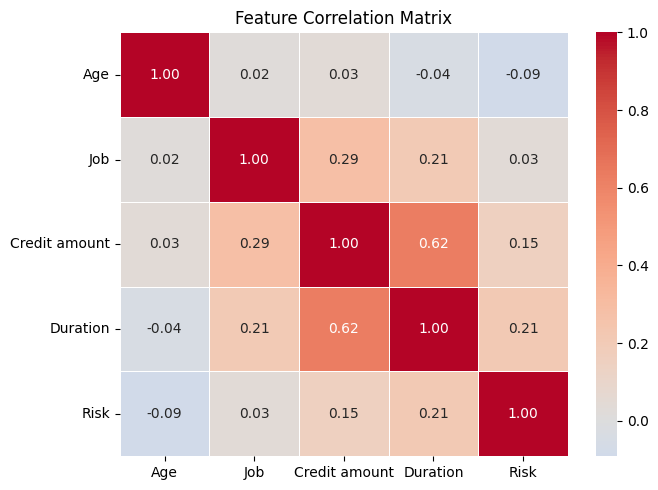

In [6]:
# ─── Correlation Matrix/heatmap ──────────────────────────────────────────────────────
# Only numeric features at this stage — categoricals aren't encoded yet.
# Risk is temporarily mapped to 0/1 so it appears in the correlation matrix.

numeric_cols = ['Age', 'Job', 'Credit amount', 'Duration', 'Risk']
heatmap_df = df[numeric_cols].copy()
heatmap_df['Risk'] = df['Risk'].replace({'good': 0, 'bad': 1})

corr_matrix = heatmap_df.corr()


plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 3. Preprocessing

In [7]:
# Fill with 'unknown' rather than dropping rows — Checking account alone has 394 nulls.
# 'unknown' becomes its own one-hot column so the model can learn its signal separately.
df = pd.read_csv('../data/german_credit_data.csv')


df['Saving accounts']  = df['Saving accounts'].fillna('unknown')   
df['Checking account'] = df['Checking account'].fillna('unknown')  
df['Monthly_payment'] = df['Credit amount'] / df['Duration']       
df['Age_to_duration'] = df['Age'] / df['Duration']
df['Credit_per_age'] = df['Credit amount'] / df['Age']
df['Credit*Duration'] = df['Credit amount'] * df['Duration']

# One-hot encode categorical features
df = pd.get_dummies(df, columns=['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose'])
# get_dummies converts each category to a 0/1 column; avoids imposing ordinal order on nominal values

# Encode target: good → 0, bad → 1
df['Risk'] = df['Risk'].map({'good': 0, 'bad': 1})  # Encoding necessary for xgboost and to ensure consistent numeric format for all models

# Drop the useless CSV index column
df = df.drop('Unnamed: 0', axis=1)  
print(df.head())  
print(df.shape)   

   Age  Job  Credit amount  Duration  Risk  Monthly_payment  Age_to_duration  \
0   67    2           1169         6     0       194.833333        11.166667   
1   22    2           5951        48     1       123.979167         0.458333   
2   49    1           2096        12     0       174.666667         4.083333   
3   45    2           7882        42     0       187.666667         1.071429   
4   53    2           4870        24     1       202.916667         2.208333   

   Credit_per_age  Credit*Duration  Sex_female  ...  Checking account_rich  \
0       17.447761             7014       False  ...                  False   
1      270.500000           285648        True  ...                  False   
2       42.775510            25152       False  ...                  False   
3      175.155556           331044       False  ...                  False   
4       91.886792           116880       False  ...                  False   

   Checking account_unknown  Purpose_business  Pur

In [8]:
# Defaulters should have higher Credit amount, longer Duration, lower account balances
df.groupby('Risk').mean().T  

Risk,0,1
Age,36.224286,33.963333
Job,1.890000,1.936667
Credit amount,2985.457143,3938.126667
Duration,19.207143,24.860000
Monthly_payment,165.819730,172.044031
Age_to_duration,2.653652,1.836418
Credit_per_age,89.571721,122.652057
Credit*Duration,75215.472857,123269.170000
Sex_female,0.287143,0.363333
Sex_male,0.712857,0.636667


In [9]:
X = df.drop('Risk', axis=1)  # feature matrix — all columns except the target
y = df['Risk']             

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      #
    random_state=42,    
    stratify=y          # preserve the 70/30 class ratio in both splits
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')  # confirm 800/200 row split

Train: (800, 30)  |  Test: (200, 30)


## 4. Modeling

All three models use  `GridSearchCV` to find the optimal recall since it is equivalent to default recognition rate  and approving a loan that defaults  is costlier than a false positive.

In [10]:
# ─── Logistic Regression ──────────────────────────────────────────────────────
# Pipeline prevents data leakage: StandardScaler is fit only on X_train.
# We tune C (regularisation strength), using recall as the scoring metric to prioritize catching bad loans.

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),                                             # normalise features so large-scale ones don't dominate the coefficients
    ('model', LogisticRegression(random_state=42, class_weight='balanced'))   # balanced automatically upweights the minority (bad) class by 700/300 ≈ 2.3×
])

param_grid_lr = {'model__C': [0.0001, 0.001, 0.01, 1, 10, 100]}  
grid_search_lr = GridSearchCV(lr_pipeline, param_grid_lr, cv=10, scoring='recall')  # 10-fold CV, pick C that maximises recall
grid_search_lr.fit(X_train, y_train)  # scaler is fit inside each CV fold to avoid leakage

print(f'Best C: {grid_search_lr.best_params_}')               # optimal regularisation strength found by grid search
print(f'Best recall (CV): {grid_search_lr.best_score_:.2f}')  # mean recall across the 10 CV folds at best C

lr_model = grid_search_lr.best_estimator_  # extract the retrained pipeline with the best hyperparameters

lr_pred = (lr_model.predict_proba(X_test)[:, 1] >= 0.52).astype(int)  # P(bad) ≥ 0.5 → predict bad; column 1 is the positive class
print('\n=== Logistic Regression (tuned) ===')
print(classification_report(y_test, lr_pred, target_names=['Good (0)', 'Bad (1)']))  # precision, recall, F1 per class on held-out test set

Best C: {'model__C': 1}
Best recall (CV): 0.72

=== Logistic Regression (tuned) ===
              precision    recall  f1-score   support

    Good (0)       0.84      0.69      0.76       140
     Bad (1)       0.49      0.70      0.58        60

    accuracy                           0.69       200
   macro avg       0.67      0.70      0.67       200
weighted avg       0.74      0.69      0.71       200



In [11]:
# ─── Random Forest ────────────────────────────────────────────────────────────
# Tune: n_estimators (ensemble size), max_depth (regularisation),
# and min_samples_leaf (prevents memorising individual applicants).

param_grid_rf = {
    'n_estimators':     [100, 200, 300],   # more trees = lower variance but slower; 300 is usually sufficient
    'max_depth':        [None, 5, 10],     # None = grow until pure leaves (overfits); 5/10 constrain complexity
    'min_samples_leaf': [1, 2, 4],         # minimum samples at a leaf; higher values smooth decision boundaries
}

rf_base = RandomForestClassifier(random_state=42, class_weight='balanced')  # balanced weights counteract the 70/30 imbalance
grid_search_rf = GridSearchCV(rf_base, param_grid_rf, cv=10, scoring='recall', n_jobs=-1)  # n_jobs=-1 uses all CPU cores
grid_search_rf.fit(X_train, y_train)  

print(f'Best RF params: {grid_search_rf.best_params_}')        
print(f'Best recall (CV): {grid_search_rf.best_score_:.2f}')  

rf_model = grid_search_rf.best_estimator_  # final model retrained on all 800 training rows

rf_pred = rf_model.predict(X_test)  # hard predictions (default 0.5 threshold)
print('\n=== Random Forest (tuned) ===')
print(classification_report(y_test, rf_pred, target_names=['Good (0)', 'Bad (1)']))  # per-class metrics on unseen test set

Best RF params: {'max_depth': 5, 'min_samples_leaf': 4, 'n_estimators': 200}
Best recall (CV): 0.68

=== Random Forest (tuned) ===
              precision    recall  f1-score   support

    Good (0)       0.86      0.72      0.79       140
     Bad (1)       0.53      0.73      0.62        60

    accuracy                           0.72       200
   macro avg       0.70      0.73      0.70       200
weighted avg       0.76      0.72      0.73       200



In [12]:
# ─── XGBoost ──────────────────────────────────────────────────────────────────
# Tune: n_estimators and learning_rate together (they trade off — lower lr needs
# more trees), and max_depth (XGBoost trees are typically kept shallow: 3–7).
# scale_pos_weight is derived from the class ratio, not a free hyperparameter.

scale_pw = (y_train == 0).sum() / (y_train == 1).sum()  # ratio of negatives to positives (≈2.33) — tells XGBoost how much to upweight bad loans

param_grid_xgb = {
    'n_estimators':  [100, 200],         # number of boosting rounds; too many → overfitting without early stopping
    'max_depth':     [3, 5, 7],          # depth of each tree; shallower trees = stronger regularisation
    'learning_rate': [0.05, 0.1, 0.3],   # shrinks each tree's contribution; smaller rate needs more trees
}

xgb_base = XGBClassifier(
    random_state=42,
    eval_metric='logloss',               # internal eval metric during training; logloss is standard for binary classification
    scale_pos_weight=scale_pw            # compensates for class imbalance by scaling the gradient for positive examples
)
grid_search_xgb = GridSearchCV(xgb_base, param_grid_xgb, cv=10, scoring='recall', n_jobs=-1)  # 2×3×3 = 18 configs × 10 folds
grid_search_xgb.fit(X_train, y_train)  # fit all configurations on the training set

print(f'Best XGBoost params: {grid_search_xgb.best_params_}')  # optimal (n_estimators, max_depth, learning_rate) triple
print(f'Best recall (CV): {grid_search_xgb.best_score_:.2f}')  # mean CV recall at the best config

xgb_model = grid_search_xgb.best_estimator_  # retrained model using best params on full training set

xgb_pred = xgb_model.predict(X_test)  # hard class predictions on held-out test rows
print('\n=== XGBoost (tuned) ===')
print(classification_report(y_test, xgb_pred, target_names=['Good (0)', 'Bad (1)']))  # per-class precision/recall/F1 on test set

Best XGBoost params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best recall (CV): 0.67

=== XGBoost (tuned) ===
              precision    recall  f1-score   support

    Good (0)       0.85      0.67      0.75       140
     Bad (1)       0.48      0.72      0.58        60

    accuracy                           0.69       200
   macro avg       0.66      0.69      0.66       200
weighted avg       0.74      0.69      0.70       200



## 5. Evaluation

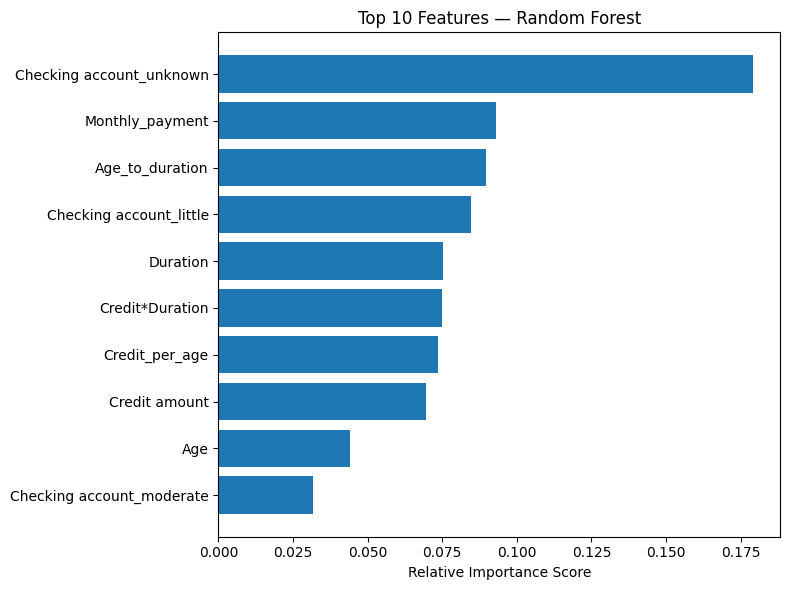

In [13]:


feat_df = pd.DataFrame({'feature': X.columns, 'importance': rf_model.feature_importances_})  # pair each feature name with its Gini importance score
feat_df = feat_df.sort_values('importance', ascending=False).head(10)  # keep only the top 10 most important features 

plt.figure(figsize=(8, 6))                              
plt.barh(feat_df['feature'], feat_df['importance'])     
plt.xlabel('Relative Importance Score')                 
plt.title('Top 10 Features — Random Forest')            
plt.gca().invert_yaxis()                                #
plt.tight_layout()                                     
plt.savefig('../results/feature_importance.png')        
plt.show()                                             

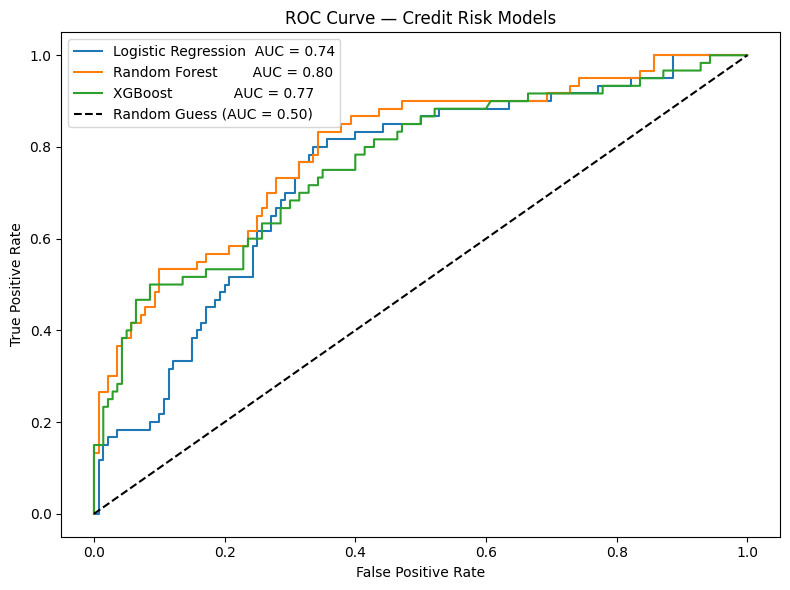

Logistic Regression AUC: 0.74
Random Forest AUC:       0.80
XGBoost AUC:             0.77


In [14]:
# ─── ROC Curves ───────────────────────────────────────────────────────────────
# AUC measures how well the model ranks a bad loan above a good one across all
# thresholds. Useful summary, but can be optimistic on imbalanced data (see PR below).

lr_probs = lr_model.predict_proba(X_test)[:, 1]   # P(bad loan) for each test applicant — LR
rf_probs = rf_model.predict_proba(X_test)[:, 1]   # P(bad loan) for each test applicant — RF
xg_probs = xgb_model.predict_proba(X_test)[:, 1]  # P(bad loan) for each test applicant — XGBoost

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)   # FPR and TPR arrays at every decision threshold — LR
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)   # FPR and TPR arrays at every decision threshold — RF
xg_fpr, xg_tpr, _ = roc_curve(y_test, xg_probs)  # FPR and TPR arrays at every decision threshold — XGBoost

lr_auc = auc(lr_fpr, lr_tpr)   # area under the LR ROC curve; 1.0 = perfect, 0.5 = random
rf_auc = auc(rf_fpr, rf_tpr)   # area under the RF ROC curve
xg_auc = auc(xg_fpr, xg_tpr)  # area under the XGBoost ROC curve

plt.figure(figsize=(8, 6))
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression  AUC = {lr_auc:.2f}')  # LR curve
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest        AUC = {rf_auc:.2f}')  # RF curve
plt.plot(xg_fpr, xg_tpr, label=f'XGBoost              AUC = {xg_auc:.2f}') # XGBoost curve
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)')          # diagonal baseline: a model with no discrimination
plt.xlabel('False Positive Rate')                   # x-axis: fraction of good loans wrongly flagged
plt.ylabel('True Positive Rate')                    # y-axis: fraction of bad loans correctly caught
plt.title('ROC Curve — Credit Risk Models')         # chart title
plt.legend()                                        # show AUC values per model
plt.tight_layout()
plt.savefig('../results/roc_curve.png')             # save to results folder for the README
plt.show()

print(f'Logistic Regression AUC: {lr_auc:.2f}')   # numeric AUC summary for quick comparison
print(f'Random Forest AUC:       {rf_auc:.2f}')
print(f'XGBoost AUC:             {xg_auc:.2f}')

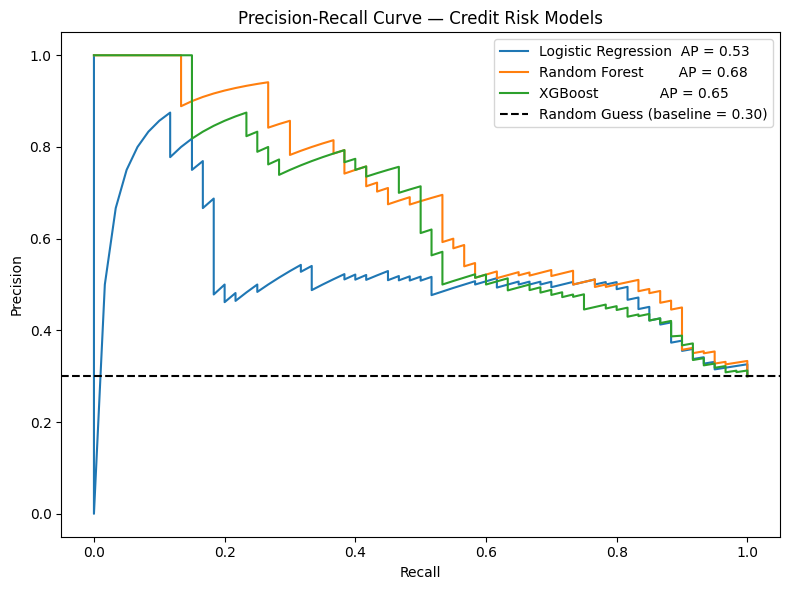

Logistic Regression AP: 0.53
Random Forest AP:       0.68
XGBoost AP:             0.65
Baseline (random):      0.30


In [15]:
# ─── Precision-Recall Curves ──────────────────────────────────────────────────
# More informative than ROC for imbalanced data: Precision = TP/(TP+FP) measures


lr_prec, lr_rec, _ = precision_recall_curve(y_test, lr_probs)  
rf_prec, rf_rec, _ = precision_recall_curve(y_test, rf_probs)   
xg_prec, xg_rec, _ = precision_recall_curve(y_test, xg_probs)  

lr_ap = average_precision_score(y_test, lr_probs)   # area under the PR curve (weighted mean precision); summary scalar — LR
rf_ap = average_precision_score(y_test, rf_probs)   # AP — RF
xg_ap = average_precision_score(y_test, xg_probs)  # AP — XGBoost
baseline = y_test.mean()                             # prevalence of bad loans (~0.30); AP of a random classifier equals this

plt.figure(figsize=(8, 6))
plt.plot(lr_rec, lr_prec, label=f'Logistic Regression  AP = {lr_ap:.2f}')  # LR PR curve
plt.plot(rf_rec, rf_prec, label=f'Random Forest        AP = {rf_ap:.2f}')  # RF PR curve
plt.plot(xg_rec, xg_prec, label=f'XGBoost              AP = {xg_ap:.2f}') # XGBoost PR curve
plt.axhline(y=baseline, color='k', linestyle='--', label=f'Random Guess (baseline = {baseline:.2f})')  # flat line at class prevalence
plt.xlabel('Recall')                                   # x-axis: fraction of actual bad loans caught
plt.ylabel('Precision')                                # y-axis: fraction of predicted bad loans that are truly bad
plt.title('Precision-Recall Curve — Credit Risk Models')
plt.legend()
plt.tight_layout()
plt.savefig('../results/pr_curve.png')                 # save for the README
plt.show()

print(f'Logistic Regression AP: {lr_ap:.2f}')   # numeric AP for quick comparison
print(f'Random Forest AP:       {rf_ap:.2f}')
print(f'XGBoost AP:             {xg_ap:.2f}')
print(f'Baseline (random):      {baseline:.2f}')  # reference: any model must beat this to be useful

In [16]:
# ─── Logistic Regression Coefficients ─────────────────────────────────────────
# Positive → feature increases P(bad loan); Negative → decreases it.
# Coefficients are comparable across features because StandardScaler
# normalised all inputs to mean=0, std=1 before training.

coef_df = pd.DataFrame({
    'feature':     X.columns,                          # feature names aligned to model coefficients
    'coefficient': lr_model.named_steps['model'].coef_[0]  # coef_[0] extracts the 1-D array for binary classification
})
coef_df = coef_df.reindex(coef_df['coefficient'].abs().sort_values(ascending=False).index)  # sort by absolute value — magnitude matters regardless of direction
coef_df.head(20)  # display the 20 strongest drivers of P(bad loan)

,feature,coefficient
5,Age_to_duration,-0.773020
21,Checking account_unknown,-0.481958
18,Checking account_little,0.332154
0,Age,0.299621
25,Purpose_education,0.236299
16,Saving accounts_rich,-0.195426
17,Saving accounts_unknown,-0.192041
2,Credit amount,-0.190513
19,Checking account_moderate,0.183383
13,Saving accounts_little,0.181409
